In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("placement.csv")

In [3]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [4]:
df.tail()

,cgpa,placement_exam_marks,placed
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1
999,4.90,10.0,1


In [5]:
df.columns

Index(['cgpa', 'placement_exam_marks', 'placed'], dtype='str')

In [6]:
df.dtypes

cgpa                    float64
placement_exam_marks    float64
placed                    int64
dtype: object

In [7]:
df.shape

(1000, 3)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cgpa                  1000 non-null   float64
 1   placement_exam_marks  1000 non-null   float64
 2   placed                1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


In [9]:
df.isnull().sum()

cgpa                    0
placement_exam_marks    0
placed                  0
dtype: int64

In [10]:
df.duplicated().sum()

19

In [11]:
df[df.duplicated()] 

,cgpa,placement_exam_marks,placed
541,6.11,18.0,1
588,6.38,25.0,0
618,6.70,22.0,0
626,7.63,19.0,1
689,8.02,67.0,0
700,6.82,16.0,1
716,7.06,19.0,1
726,7.93,25.0,0
727,7.00,30.0,0
776,7.08,30.0,0


In [12]:
df.drop_duplicates(inplace = True)

In [13]:
df.duplicated().sum()

0

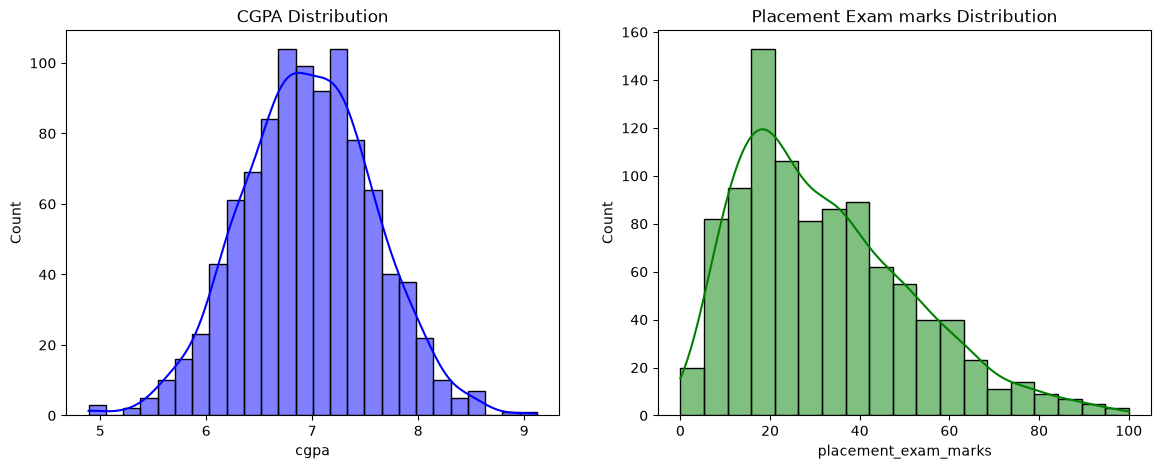

In [14]:
fig , axes = plt.subplots(1,2, figsize = (14,5))

sns.histplot(df['cgpa'], kde = True , ax = axes[0], color = 'blue')
axes[0].set_title('CGPA Distribution')

sns.histplot(df['placement_exam_marks'], kde = True, ax = axes[1], color = 'green')
axes[1].set_title("Placement Exam marks Distribution")

plt.show()

In [15]:
# Outlier Detection and Handling

In [16]:
cg_mean = df['cgpa'].mean()
cg_std = df['cgpa'].std()

highest_allowed = cg_mean + 3*cg_std
lowest_allowed = cg_mean - 3*cg_std

print("Highest Allowed CGPA:", highest_allowed)
print("Lowest Allowed CGPA:", lowest_allowed)

Highest Allowed CGPA: 8.814580901646803
Lowest Allowed CGPA: 5.107682095295093


In [17]:
cg_outliers = df[(df['cgpa'] > highest_allowed) | (df['cgpa'] < lowest_allowed)]

cg_outliers

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [18]:
# Capping (cap the outliers at the upper and lower limits)

df['cgpa'] = np.where(
    df['cgpa'] > highest_allowed,
    highest_allowed,
    np.where(
        df['cgpa'] < lowest_allowed,
        lowest_allowed,
        df['cgpa']
    )
)

# verifying
df[(df['cgpa'] > highest_allowed) | (df['cgpa'] < lowest_allowed)]

,cgpa,placement_exam_marks,placed


In [19]:
df['cgpa'].describe()

count    981.000000
mean       6.961389
std        0.614644
min        5.107682
25%        6.550000
50%        6.960000
75%        7.370000
max        8.814581
Name: cgpa, dtype: float64

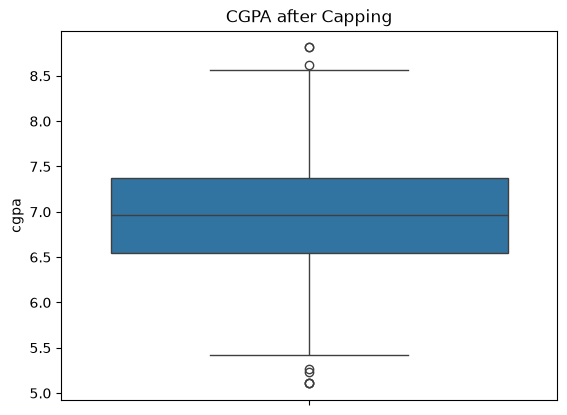

In [20]:
sns.boxplot(df['cgpa'])
plt.title("CGPA after Capping")
plt.show()

In [21]:
X = df[['cgpa','placement_exam_marks']]
y = df['placed']

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train , X_test , y_train , y_test = train_test_split(
    X , y , test_size = 0.2 , random_state = 42)

In [24]:
from sklearn.preprocessing import StandardScaler

In [25]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [26]:
from sklearn.linear_model import LogisticRegression

In [27]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [28]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [30]:
y_pred = lr.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.4873096446700508

Confusion Matrix:
 [[47 58]
 [43 49]]

Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.45      0.48       105
           1       0.46      0.53      0.49        92

    accuracy                           0.49       197
   macro avg       0.49      0.49      0.49       197
weighted avg       0.49      0.49      0.49       197

